In [1]:

import numpy as np
from matplotlib import rcParams, pyplot as plt
from astropy.io import fits
from pathlib import Path


In [2]:

plotpath = Path('/Volumes/Data/jupyterplots')
plotpath.mkdir(parents=True, exist_ok=True)


In [3]:

def make_wavelength_axis(header, nw):
    if 'STARTWV' in header and 'ENDWV' in header:
      startwv = header['STARTWV']
      endwv = header['ENDWV']
      refwv = header.get('REFWV', 0.0)
      return np.linspace(startwv, endwv, nw, dtype=float)+refwv

    print('Warning: no wavelength metadata found in header; using channel index')
    return np.arange(nw, dtype=float)


In [4]:

datadir = Path('/Volumes/Data/Data/')
files = sorted(datadir.glob('*.fts'))
if not files:
    raise FileNotFoundError(f'No FITS files found in {datadir}')
file = files[0]
print(f'datadir = {datadir}')
print(f'file = {file}')
print(f'total files = {len(files)}')


datadir = /Volumes/Data/Data
file = /Volumes/Data/Data/cal_230831_194527.fts
total files = 1


In [5]:
with fits.open(file, memmap=False) as hdulist:
    data = hdulist[0].data.astype(np.float32, copy=False)
    nstk, nw, ny, nx = data.shape
    header = hdulist[0].header
    w = make_wavelength_axis(header, nw)

print('nstk =', nstk, 'nw =', nw, 'ny =', ny, 'nx =', nx)


nstk = 4 nw = 41 ny = 720 nx = 720


In [6]:

windex = 38
base = data[0, windex].astype(np.float32)

ratioQ = np.divide(data[1, windex], base, out=np.zeros_like(base), where=base!=0)
ratioU = np.divide(data[2, windex], base, out=np.zeros_like(base), where=base!=0)
ratioV = np.divide(data[3, windex], base, out=np.zeros_like(base), where=base!=0)


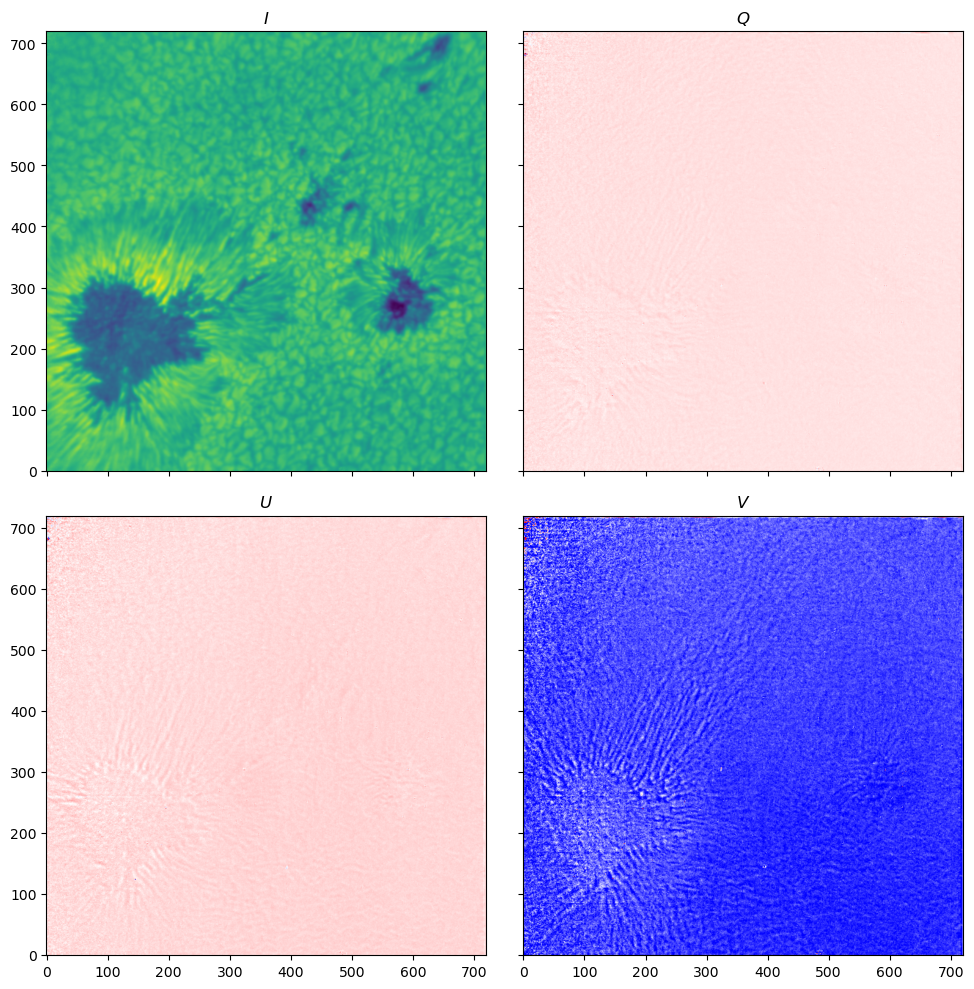

In [7]:


fig, axs = plt.subplots(2, 2, figsize=(10, 10))


axs[0, 0].imshow(base, origin='lower')
axs[0, 0].set_title(r'$I$')
axs[0, 1].imshow(ratioQ, origin='lower', cmap='bwr', vmin=-0.1, vmax=0.1)
axs[0, 1].set_title(r'$Q$')
axs[1, 0].imshow(ratioU, origin='lower', cmap='bwr', vmin=-0.06, vmax=0.06)
axs[1, 0].set_title(r'$U$')
axs[1, 1].imshow(ratioV, origin='lower', cmap='bwr', vmin=-0.01, vmax=0.01)
axs[1, 1].set_title(r'$V$')


axs[0, 0].tick_params(labelbottom=False)
axs[0, 1].tick_params(labelbottom=False, labelleft=False)
axs[1, 1].tick_params(labelleft=False)


fig.tight_layout()
plt.show()



In [8]:

iy, ix = 360, 200
slice1 = slice(7, nw)
slice2 = slice(41-7, nw)


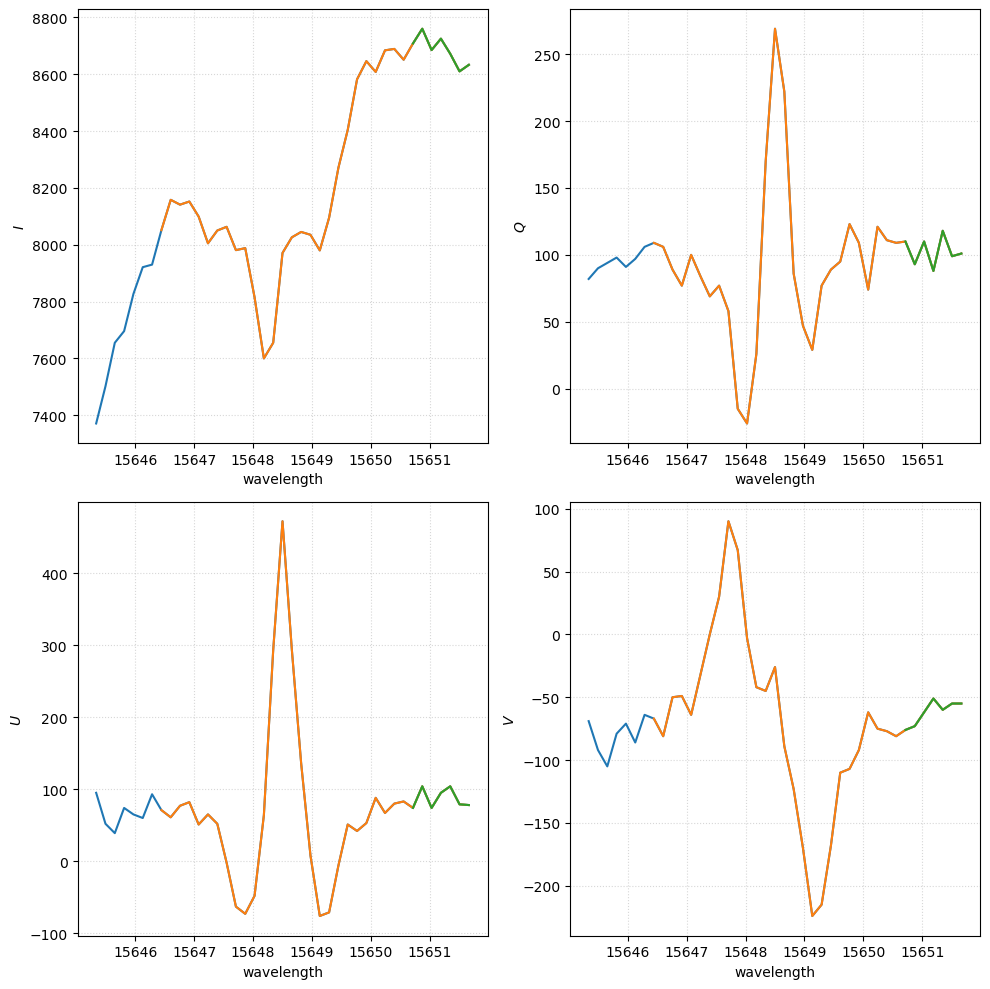

In [9]:
labels = [r'$I$', r'$Q$', r'$U$', r'$V$']

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for indx, ax in enumerate(axs.flat):
    ax.plot(w, data[indx, :, iy, ix], color='tab:blue')
    ax.plot(w[slice1], data[indx, slice1, iy, ix], color='tab:orange')
    ax.plot(w[slice2], data[indx, slice2, iy, ix], color='tab:green')
    ax.set_xlabel('wavelength')
    ax.set_ylabel(labels[indx])
    ax.grid(True, linestyle=':', alpha=0.5)
fig.tight_layout()
plt.show()

In [10]:


Islice = data[0,slice2,:,:]           
Qslice = data[1,slice2,:,:]
Uslice = data[2,slice2,:,:]
Vslice = data[3,slice2,:,:]

II = np.mean(Islice*Islice, axis=0)                
QQ = np.mean(Qslice*Islice, axis=0)/II
UU = np.mean(Uslice*Islice, axis=0)/II
VV = np.mean(Vslice*Islice, axis=0)/II

datacal = np.empty_like(data, dtype=np.float32)
datacal[0,:,:,:] = data[0,:,:,:]
datacal[1,:,:,:] = data[1,:,:,:] - QQ[np.newaxis,:,:]*data[0,:,:,:]
datacal[2,:,:,:] = data[2,:,:,:] - UU[np.newaxis,:,:]*data[0,:,:,:]
datacal[3,:,:,:] = data[3,:,:,:] - VV[np.newaxis,:,:]*data[0,:,:,:]


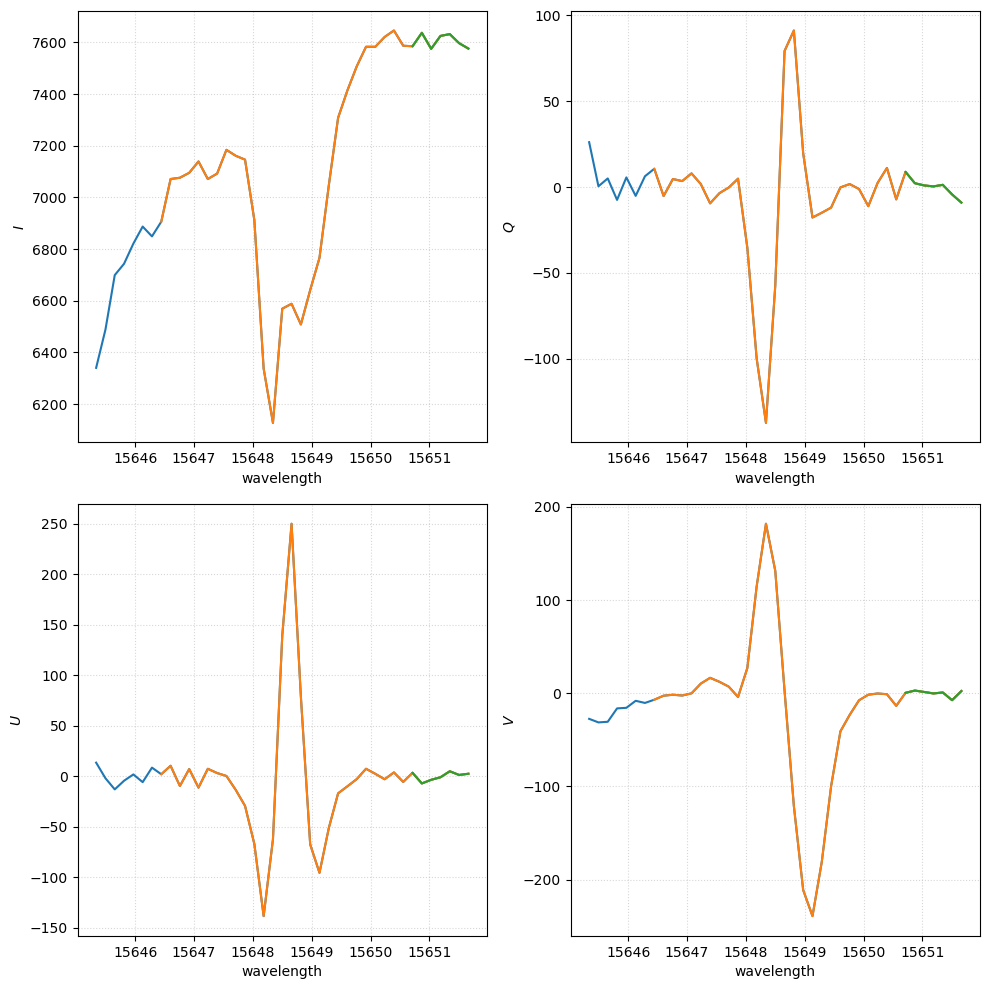

In [11]:
iy,ix = 391, 562

labels = [r'$I$', r'$Q$', r'$U$', r'$V$']

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for indx, ax in enumerate(axs.flat):
    ax.plot(w, datacal[indx, :, iy,ix], color='tab:blue')
    ax.plot(w[slice1], datacal[indx, slice1, iy,ix], color='tab:orange')
    ax.plot(w[slice2], datacal[indx, slice2, iy,ix], color='tab:green')
    ax.set_xlabel('wavelength')
    ax.set_ylabel(labels[indx])
    ax.grid(True, linestyle=':', alpha=0.5)
fig.tight_layout()
plt.show()


In [12]:
datap = datacal[:,slice1,:,:].transpose([2,3,0,1])
datap = np.asarray(datap, dtype=np.float32)
wp = np.asarray(w[slice1], dtype=np.float32)
output_data = datadir/'niris_exampletest.fits'
output_wave = datadir/'niriswavelengthtest.fits'

fits.PrimaryHDU(datap).writeto(output_data, overwrite=True)
fits.PrimaryHDU(wp).writeto(output_wave, overwrite=True)
print('saved', output_data)
print('saved', output_wave)


saved /Volumes/Data/Data/niris_exampletest.fits
saved /Volumes/Data/Data/niriswavelengthtest.fits
